/tmp/ipykernel_6535/3998997779.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2015-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0052
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.0051e-04
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.9054e-04
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.0615e-04
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.5135e-04


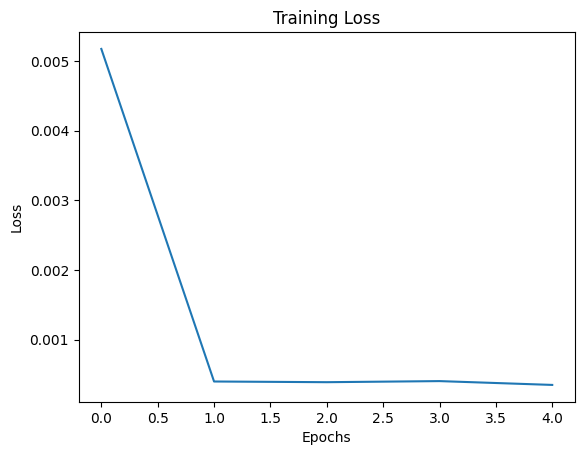

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


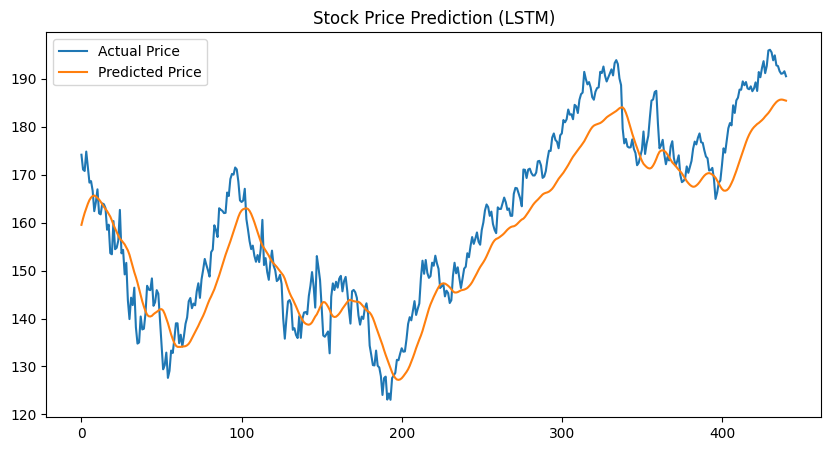

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


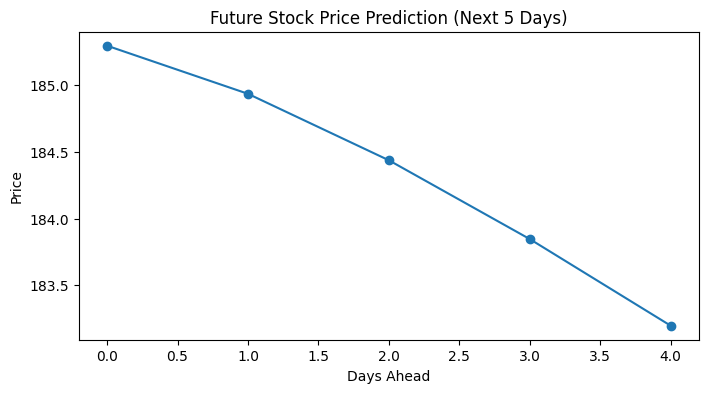

Future Predictions: [185.2972  184.93643 184.43777 183.84673 183.19704]


In [ ]:
# ================================
# RNN (LSTM) for Stock Prediction
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# 1. Load Stock Data (Apple)
df = yf.download('AAPL', start='2015-01-01', end='2023-12-31')

# 2. Use Closing Price
data = df[['Close']]

# 3. Normalize Data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# 4. Create Sequences (Time Steps)
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# 5. Split Train/Test
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# 7. Build Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60,1)),
    LSTM(50),
    Dense(1)
])

# 8. Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')

# 9. Train Model
model.fit(X_train, y_train, epochs=5, batch_size=32)

plt.plot(model.history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# 10. Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 11. Inverse Transform
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# 12. Plot Results
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(test_pred, label='Predicted Price')
plt.legend()
plt.title("Stock Price Prediction (LSTM)")
plt.show()

model.summary()

# =========================================
# Future Prediction
# =========================================

future_days = 5

last_sequence = scaled_data[-60:]
future_predictions = []

current_input = last_sequence.reshape(1, 60, 1)

for _ in range(future_days):
    next_pred = model.predict(current_input)

    future_predictions.append(next_pred[0][0])

    # FIX: reshape properly to (1,1,1)
    next_pred_reshaped = next_pred.reshape(1,1,1)

    # slide window
    current_input = np.concatenate(
        (current_input[:,1:,:], next_pred_reshaped),
        axis=1
    )

# Convert back to original scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

# Plot
plt.figure(figsize=(8,4))
plt.plot(future_predictions, marker='o')
plt.title("Future Stock Price Prediction (Next 5 Days)")
plt.xlabel("Days Ahead")
plt.ylabel("Price")
plt.show()

print("Future Predictions:", future_predictions.flatten())